#  Notebook 06 — Regional & Seller Analysis
## Goal: Understand geographic performance and seller behavior
**Business Value:** Identify expansion opportunities, operational bottlenecks, top sellers
**Tools:** Python, Pandas, Matplotlib, Seaborn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

master =pd.read_csv("../data/processed/master_clean.csv")

date_cols =[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    master[col] = pd.to_datetime(master[col], errors ='coerce')

print(" Data Loaded")
print(f" Shape: {master.shape[0]:,} rows x {master.shape[1]} columns")
print(f" Unique customer stats : {master['customer_state'].nunique()}")
print(f" Unique sellers        : {master['seller_id'].nunique():,}")


 Data Loaded
 Shape: 119,143 rows x 28 columns
 Unique customer stats : 27
 Unique sellers        : 3,095


## Question 1 Revenue by Customer State

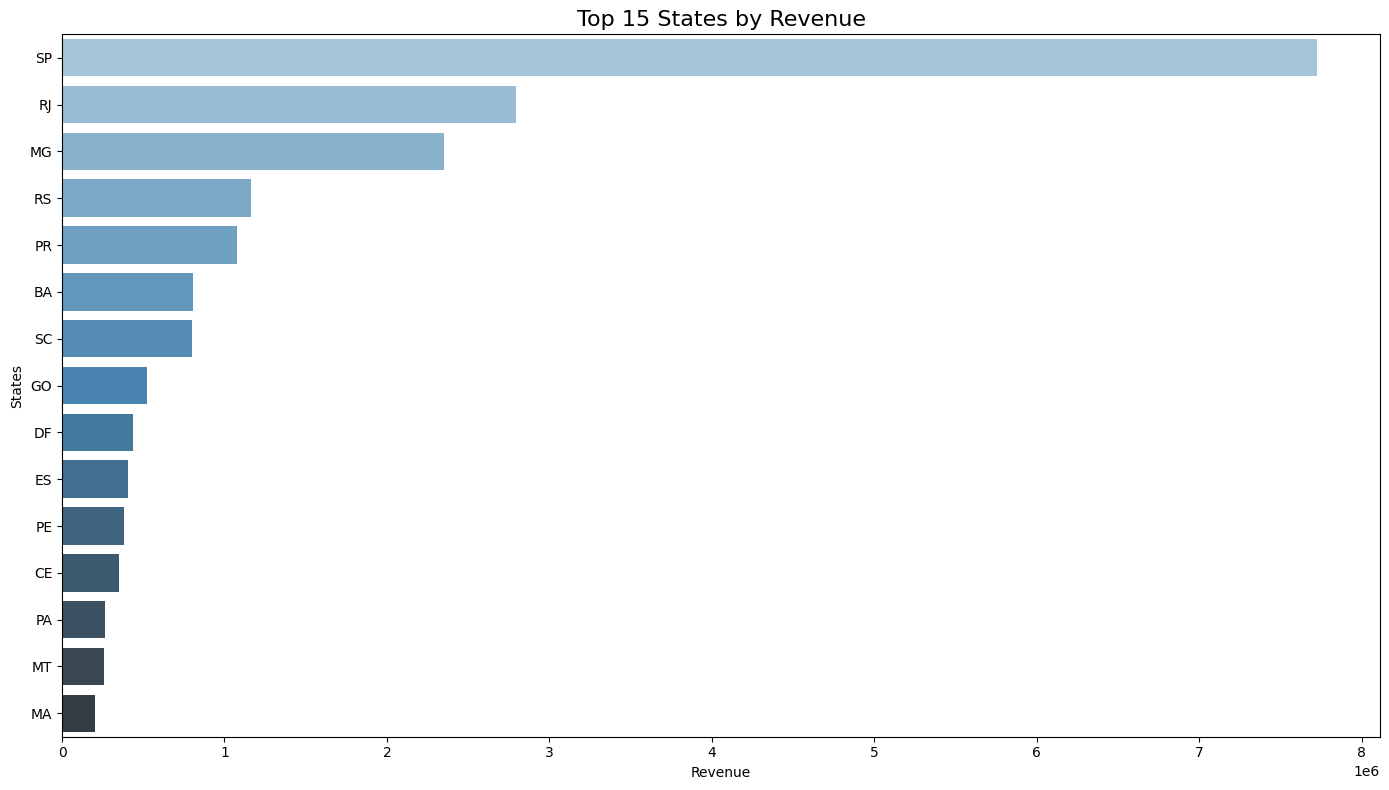

 Revenue by State - Top 15:
 SP    ->    7,726,078 (37.5%)
 RJ    ->    2,795,616 (13.6%)
 MG    ->    2,351,221 (11.4%)
 RS    ->    1,160,176 (5.6%)
 PR    ->    1,079,795 (5.2%)
 BA    ->      805,071 (3.9%)
 SC    ->      801,276 (3.9%)
 GO    ->      520,482 (2.5%)
 DF    ->      438,095 (2.1%)
 ES    ->      408,612 (2.0%)
 PE    ->      380,294 (1.8%)
 CE    ->      349,290 (1.7%)
 PA    ->      263,218 (1.3%)
 MT    ->      257,802 (1.3%)
 MA    ->      200,363 (1.0%)


In [8]:
state_revenue =master.groupby('customer_state')['payment_value'].sum().reset_index()
state_revenue.columns = ['state','revenue']
state_revenue = state_revenue.sort_values('revenue', ascending=False)

total = state_revenue['revenue'].sum()
state_revenue['revenue_pct'] = (state_revenue['revenue'] / total * 100).round(1)

top15_states=state_revenue.head(15)

plt.figure(figsize=(14,8))
sns.barplot(data=top15_states, y='state',x='revenue', palette='Blues_d')
plt.title('Top 15 States by Revenue', fontsize=16)
plt.xlabel('Revenue')
plt.ylabel('States')
plt.tight_layout()
plt.savefig('../visuals/23_state_revenue.png', dpi=150)
plt.show()

print(" Revenue by State - Top 15:")
for _, row in top15_states.iterrows():
    print(f" {row['state']:5s} -> {row['revenue']:>12,.0f} ({row['revenue_pct']}%)")

## Question 2  Orders by State

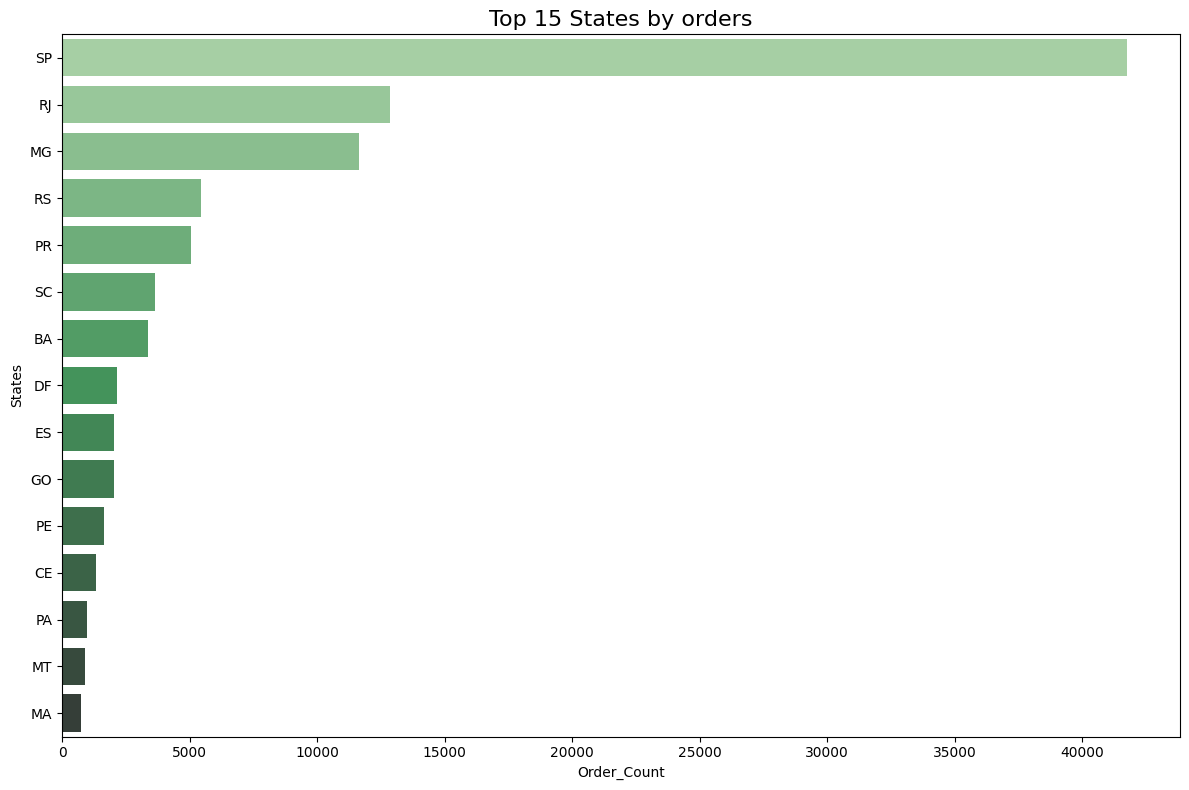

Orders  by state - Top 15:
 SP    ->   41,746 orders
 RJ    ->   12,852 orders
 MG    ->   11,635 orders
 RS    ->    5,466 orders
 PR    ->    5,045 orders
 SC    ->    3,637 orders
 BA    ->    3,380 orders
 DF    ->    2,140 orders
 ES    ->    2,033 orders
 GO    ->    2,020 orders
 PE    ->    1,652 orders
 CE    ->    1,336 orders
 PA    ->      975 orders
 MT    ->      907 orders
 MA    ->      747 orders

 Revenue Rank vs Order Rank - Top 5:
 By Revenue : ['SP', 'RJ', 'MG', 'RS', 'PR']
 By Orders : ['SP', 'RJ', 'MG', 'RS', 'PR']


In [16]:
state_orders = master.groupby('customer_state')['order_id'].nunique().reset_index()
state_orders.columns=['state','order_count']
state_orders= state_orders.sort_values('order_count', ascending=False)

top15_orders= state_orders.head(15)

plt.figure(figsize=(12,8))
sns.barplot(data=top15_orders, y='state', x='order_count', palette='Greens_d')
plt.title('Top 15 States by orders', fontsize=16)
plt.xlabel('Order_Count')
plt.ylabel('States')
plt.tight_layout()
plt.show()

print("Orders  by state - Top 15:")
for _, row in top15_orders.head(15).iterrows():
    print(f" {row['state']:5s} -> {row['order_count']:>8,} orders")

print("\n Revenue Rank vs Order Rank - Top 5:")
print(f" By Revenue : {state_revenue.head(5)['state'].tolist()}")
print(f" By Orders : {state_orders.head(5)['state'].tolist()}")

## Question 3 Average Delivery Time by State

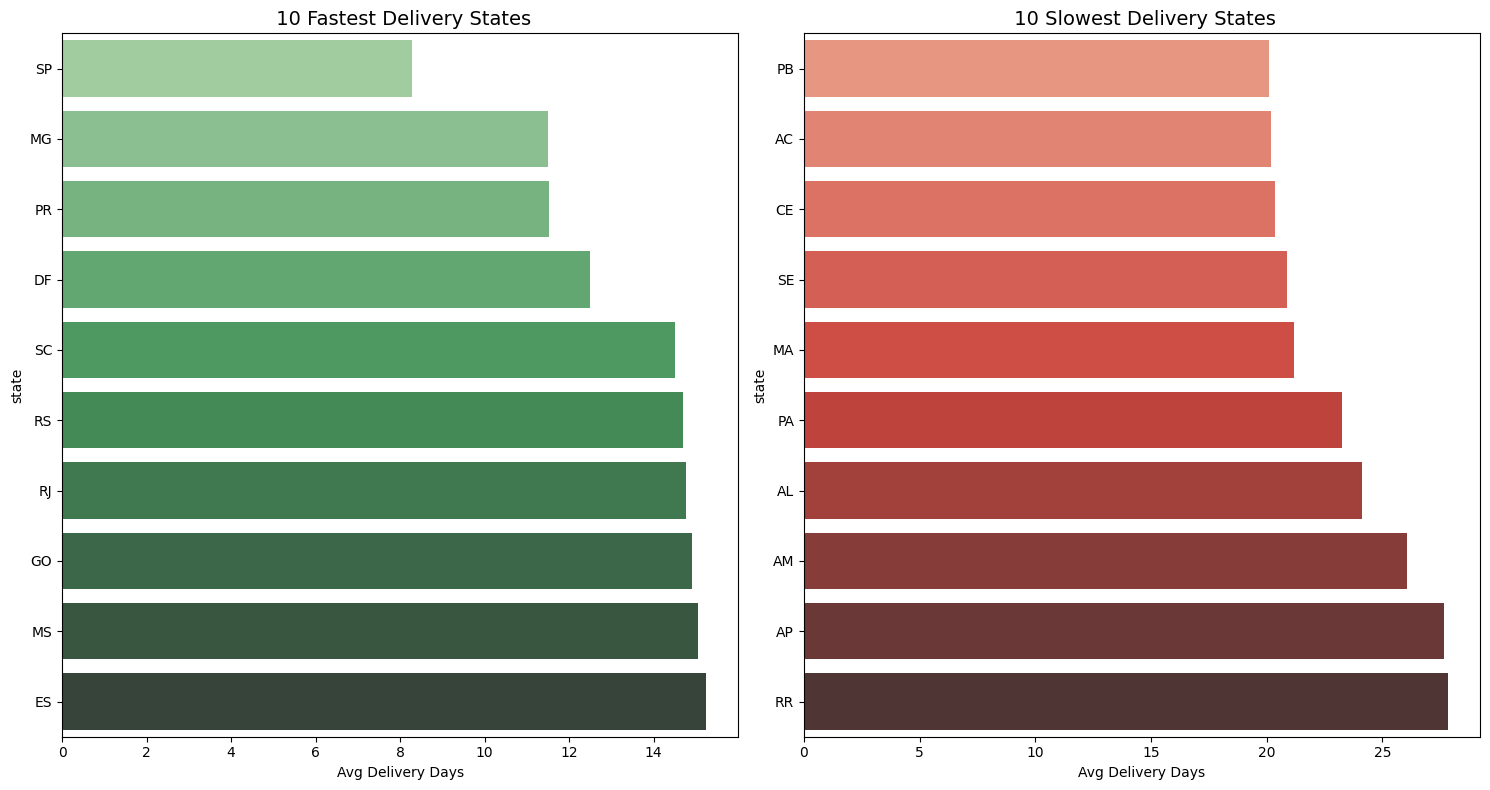

 Fastest: SP - 8.3 days
 Slowest: RR - 27.8 days


In [27]:
delivered = master[master['order_status'] =='delivered'].copy()

delivered['delivered_days']= (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days

state_delivery = delivered.groupby('customer_state')['delivered_days'].mean().reset_index()
state_delivery.columns=['state','avg_delivery_days']
state_delivery= state_delivery.sort_values('avg_delivery_days')


fig, axes= plt.subplots(1,2, figsize=(15,8))

fastest=state_delivery.head(10)
sns.barplot(data=fastest, y='state', x='avg_delivery_days', palette='Greens_d', ax=axes[0])
axes[0].set_title(' 10 Fastest Delivery States', fontsize=14)
axes[0].set_xlabel('Avg Delivery Days')

slowest=state_delivery.tail(10)
sns.barplot(data=slowest, y='state', x='avg_delivery_days', palette='Reds_d', ax=axes[1])
axes[1].set_title(' 10 Slowest Delivery States', fontsize=14)
axes[1].set_xlabel('Avg Delivery Days')

plt.tight_layout()
plt.savefig('../visuals/25_delivery_by_states.png',dpi=150)
plt.show()

fastest_state = state_delivery.iloc[0]
slowest_state = state_delivery.iloc[-1]

print(f" Fastest: {fastest_state['state']} - {fastest_state['avg_delivery_days']:.1f} days")
print(f" Slowest: {slowest_state['state']} - {slowest_state['avg_delivery_days']:.1f} days")

## Question 4 Review Score by State

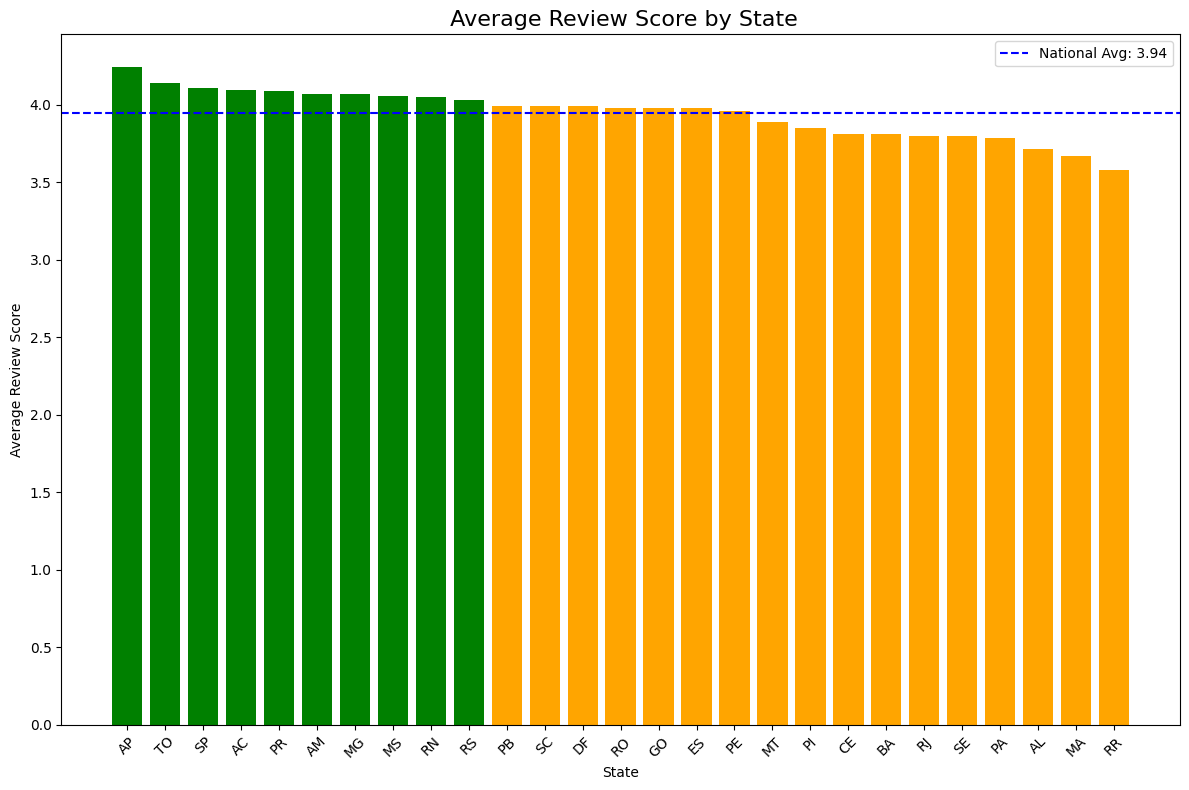

 Correlation - Delivery Time vs Review Score: -0.370
 Meaning Slower delivery = lower reviews confirmed 


In [31]:
state_reviews = master.groupby('customer_state')['review_score'].mean().reset_index()
state_reviews.columns = ['state', 'avg_review']
state_reviews = state_reviews.sort_values('avg_review', ascending=False)

plt.figure(figsize=(12, 8))
colors = ['green' if x >= 4.0 else 'orange' if x >= 3.5 else 'red'
          for x in state_reviews['avg_review']]
plt.bar(state_reviews['state'], state_reviews['avg_review'], color=colors)
plt.axhline(y=state_reviews['avg_review'].mean(), color='blue',
            linestyle='--', label=f"National Avg: {state_reviews['avg_review'].mean():.2f}")
plt.title(' Average Review Score by State', fontsize=16)
plt.xlabel('State')
plt.ylabel('Average Review Score')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/26_review_by_state.png', dpi=150)
plt.show()

state_combined = state_delivery.merge(state_reviews, on='state')
correlation = np.corrcoef(
    state_combined['avg_delivery_days'],
    state_combined['avg_review'])[0][1]
print(f" Correlation - Delivery Time vs Review Score: {correlation:.3f}")
print(f" Meaning {'Slower delivery = lower reviews confirmed ' if correlation <-0.3 else 'Weak realtionship'}")

##  Question 5 Top and Bottom Performing Sellers

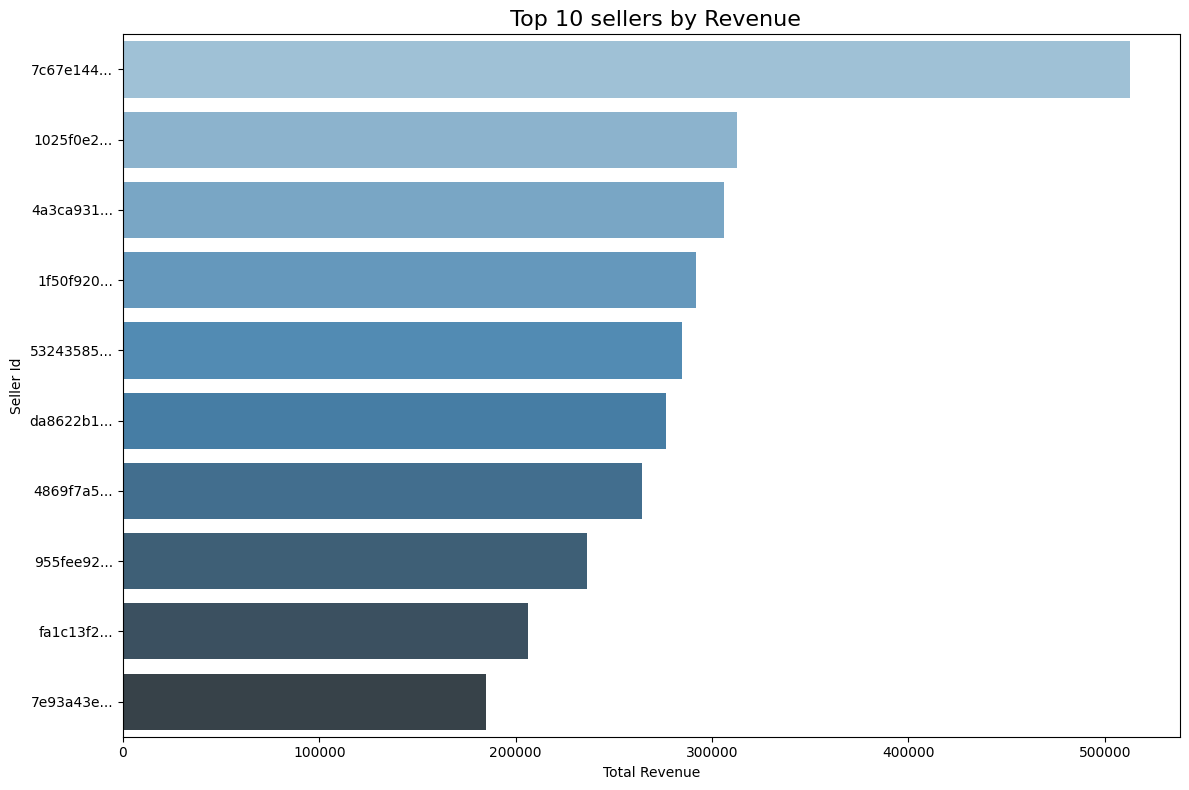

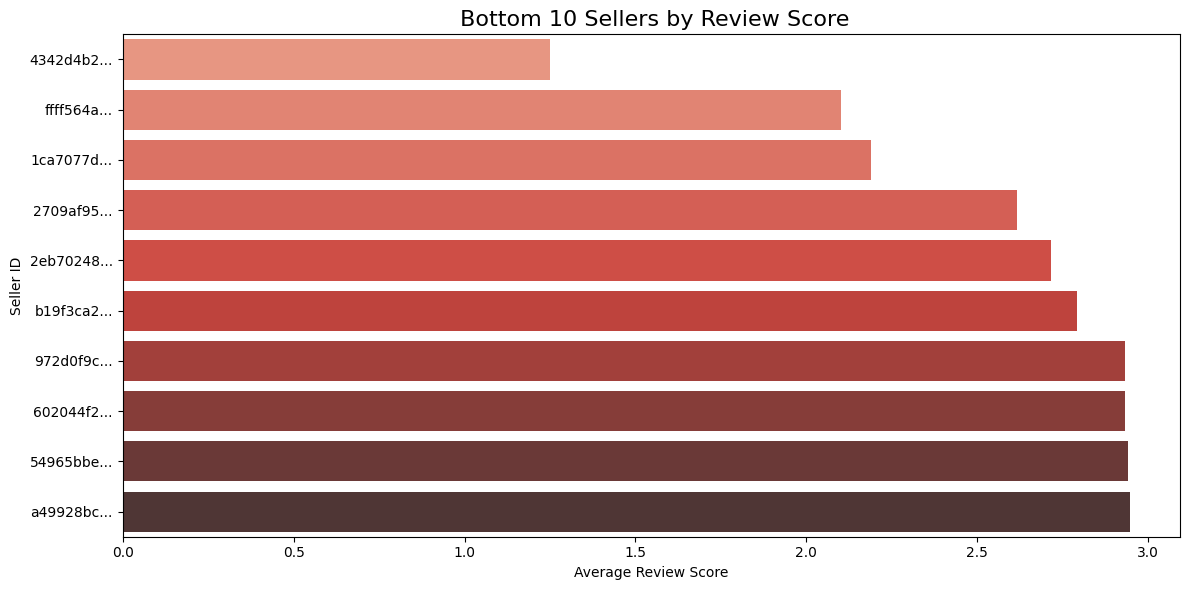

 Total Qualified Sellers: 818
 Top Seller Revenue     : 512,645
 Worst Seller Average Review : 1.25


In [41]:
seller_pref = master.groupby('seller_id').agg(
    Revenue =('payment_value','sum'),
    Orders = ('order_id','nunique'),
    Avg_Review = ('review_score','mean'),
    Avg_Delivery= ('order_delivered_customer_date',lambda x:
                   (x- master.loc[x.index, 'order_purchase_timestamp']).dt.days.mean()
                   if x.notna().any() else np.nan)
).reset_index()

seller_pref= seller_pref[seller_pref['Orders'] >=20]

seller_pref['seller_short'] = seller_pref['seller_id'].str[:8]+'...'

top_sellers = seller_pref.sort_values('Revenue', ascending=False).head(10)


plt.figure(figsize=(12,8))
sns.barplot(data=top_sellers, y='seller_short',x='Revenue',palette='Blues_d')
plt.title(' Top 10 sellers by Revenue', fontsize=16)
plt.xlabel('Total Revenue')
plt.ylabel('Seller Id')
plt.tight_layout()
plt.savefig('../visuals/27_top_sellers.png', dpi=150)
plt.show()


worst_sellers = seller_pref.sort_values('Avg_Review').head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=worst_sellers, y='seller_short', x='Avg_Review', palette='Reds_d')
plt.title(' Bottom 10 Sellers by Review Score', fontsize=16)
plt.xlabel('Average Review Score')
plt.ylabel('Seller ID')
plt.tight_layout()
plt.savefig('../visuals/28_worst_sellers.png', dpi=150)
plt.show()

print(f" Total Qualified Sellers: {len(seller_pref):,}")
print(f" Top Seller Revenue     : {top_sellers.iloc[0]['Revenue']:,.0f}")
print(f" Worst Seller Average Review : {worst_sellers.iloc[0]['Avg_Review']:,.2f}")


##  Question 6 Seller State Concentration

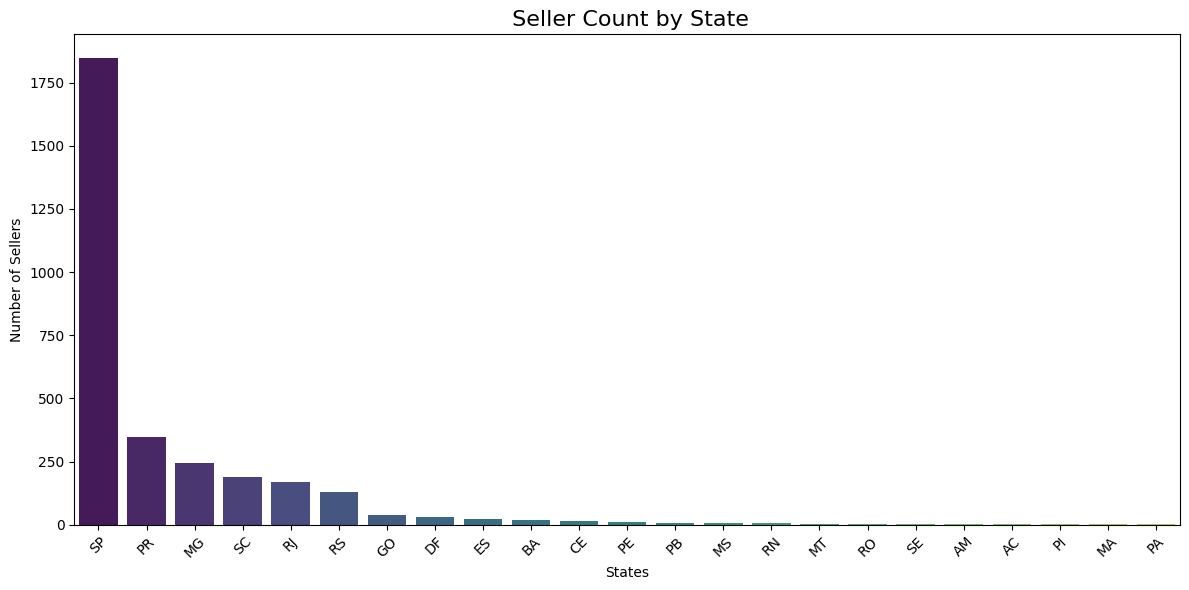

 Seller Distribution by States:
 SP    -> 1,849 sellers (59.7%)
 PR    ->  349 sellers (11.3%)
 MG    ->  244 sellers (7.9%)
 SC    ->  190 sellers (6.1%)
 RJ    ->  171 sellers (5.5%)
 RS    ->  129 sellers (4.2%)
 GO    ->   40 sellers (1.3%)
 DF    ->   30 sellers (1.0%)
 ES    ->   23 sellers (0.7%)
 BA    ->   19 sellers (0.6%)

 Top 3 states hold 78.9% of all sellers
 High concentration risk — diversify seller base


In [49]:
seller_states = master.groupby('seller_state')['seller_id'].nunique().reset_index()
seller_states.columns=['states','seller_count']
seller_states = seller_states.sort_values('seller_count',ascending=False)

total_sellers = seller_states['seller_count'].sum()
seller_states['pct'] = (seller_states['seller_count'] / total_sellers *100).round(1)

plt.figure(figsize=(12,6))
sns.barplot(data=seller_states, x='states', y='seller_count', palette='viridis')
plt.title(' Seller Count by State', fontsize=16)
plt.xlabel('States')
plt.ylabel('Number of Sellers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/29_seller_distribution.png', dpi=150)
plt.show()

top3_pct = seller_states.head(3)['pct'].sum()
print(f" Seller Distribution by States:")
for _,row in seller_states.head(10).iterrows():
    print(f" {row['states']:5s} -> {row['seller_count']:4,} sellers ({row['pct']}%)")

print(f"\n Top 3 states hold {top3_pct:.1f}% of all sellers")
print(f" {'High concentration risk — diversify seller base' if top3_pct > 70 else 'Reasonable distribution'}")

##  Question 7  Business Recommendations

In [51]:

top_revenue_state = state_revenue.iloc[0]['state']
top_revenue_val = state_revenue.iloc[0]['revenue']
slowest_state_name = state_delivery.iloc[-1]['state']
slowest_days = state_delivery.iloc[-1]['avg_delivery_days']
fastest_state_name = state_delivery.iloc[0]['state']
top_seller_rev = top_sellers.iloc[0]['Revenue']
concentration = seller_states.head(3)['pct'].sum()

print("=" * 60)
print("  REGIONAL ANALYSIS — BUSINESS RECOMMENDATIONS")
print("=" * 60)
print(f"""
    STRONGEST MARKET — {top_revenue_state}
   Revenue:  {top_revenue_val:,.0f}
   → Protect this market — highest priority for logistics
   → Ensure top seller availability here
   → Any service disruption here = maximum revenue impact

     WORST DELIVERY STATE — {slowest_state_name}
   Average {slowest_days:.1f} days to deliver
   → Investigate carrier partnerships in this region
   → Consider local seller recruitment to reduce distance
   → Customers here likely have lowest satisfaction scores

     BEST DELIVERY STATE — {fastest_state_name}
   → Study what works here — apply to other regions
   → Use as benchmark for operational excellence

      SELLER CONCENTRATION RISK
   Top 3 states hold {concentration:.1f}% of all sellers
   → {'Critical — recruit sellers in other regions urgently' if concentration > 70 else 'Manageable — continue diversification efforts'}
   → Diversified seller base = faster delivery nationwide
   → Lower freight costs = higher conversion rates

     TOP PRIORITIES:
   1. Fix delivery in {slowest_state_name} — biggest satisfaction gap
   2. Protect {top_revenue_state} market — highest revenue risk
   3. Recruit sellers outside top 3 states
   4. Use delivery time improvement to drive review scores up
""")
print("=" * 60)

  REGIONAL ANALYSIS — BUSINESS RECOMMENDATIONS

    STRONGEST MARKET — SP
   Revenue:  7,726,078
   → Protect this market — highest priority for logistics
   → Ensure top seller availability here
   → Any service disruption here = maximum revenue impact

     WORST DELIVERY STATE — RR
   Average 27.8 days to deliver
   → Investigate carrier partnerships in this region
   → Consider local seller recruitment to reduce distance
   → Customers here likely have lowest satisfaction scores

     BEST DELIVERY STATE — SP
   → Study what works here — apply to other regions
   → Use as benchmark for operational excellence

      SELLER CONCENTRATION RISK
   Top 3 states hold 78.9% of all sellers
   → Critical — recruit sellers in other regions urgently
   → Diversified seller base = faster delivery nationwide
   → Lower freight costs = higher conversion rates

     TOP PRIORITIES:
   1. Fix delivery in RR — biggest satisfaction gap
   2. Protect SP market — highest revenue risk
   3. Recruit sel